# Consolidated PA Dataset

This notebook summarizes the complete analysis-ready dataset for Pennsylvania weather stations: `data/pa_data.csv`. 213 stations were pulled in total from [GHCN](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily).



What we may want later on:
- Geopotential height patterns (EOF loadings?)

## Column Reference

### Response variable and station identifiers

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `station_id` | GHCN station identifier (e.g. USC00366233) | -- | GHCN |
| `station_name` | Human-readable station name | -- | GHCN |
| `state` | Two-letter state code (all PA here) | -- | GHCN |
| `year` | Calendar year | -- | -- |
| `latitude` | Station latitude | degrees N | GHCN |
| `longitude` | Station longitude | degrees E (negative = W) | GHCN |
| `growing_season_length` | Days between last spring frost and first fall frost | days | Computed from TMIN |
| `last_spring_frost_doy` | Day of year of last spring frost (before Jul 1) | DOY | Computed from TMIN |
| `last_spring_frost_date` | Date of last spring frost | YYYY-MM-DD | Computed from TMIN |
| `first_fall_frost_doy` | Day of year of first fall frost (after Jul 1) | DOY | Computed from TMIN |
| `first_fall_frost_date` | Date of first fall frost | YYYY-MM-DD | Computed from TMIN |

### Station-level climate variables (vary by station AND year)

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `dtr_annual` | Annual mean diurnal temperature range (TMAX - TMIN) | deg C | GHCN TMAX/TMIN |
| `dtr_spring` | Spring (Mar-May) mean DTR | deg C | GHCN TMAX/TMIN |
| `dtr_summer` | Summer (Jun-Aug) mean DTR | deg C | GHCN TMAX/TMIN |
| `tmax_annual` | Annual mean daily maximum temperature | deg C | GHCN TMAX |
| `prcp_annual_mm` | Annual total precipitation | mm | GHCN PRCP |
| `prcp_growing_season_mm` | Total precipitation during the frost-free growing season | mm | GHCN PRCP |
| `prcp_spring_mm` | Spring (Mar-May) total precipitation | mm | GHCN PRCP |

### Geographic predictors (static per station, do not vary by year)

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `elevation_m` | Station elevation above sea level | m | GHCN metadata (`ghcnd-stations.txt`) |
| `dist_coast_km` | Distance to nearest large water body (Atlantic, Gulf, OR Great Lakes) | km | Computed (haversine) |
| `dist_atlantic_km` | Distance to nearest Atlantic/Gulf coast point | km | Computed (haversine) |
| `dist_greatlakes_km` | Distance to nearest Great Lakes shoreline point | km | Computed (haversine) |

### Climate teleconnection indices (vary by year only -- same value for all stations in a given year)

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `oni_annual` | Annual mean Oceanic Nino Index (ENSO indicator) | unitless | NOAA CPC, 1950+ |
| `nao_annual` | Annual mean North Atlantic Oscillation index | unitless | NOAA CPC, 1950+ |
| `nao_djf` | Winter (Jan-Feb) NAO index | unitless | NOAA CPC, 1950+ |
| `pna_annual` | Annual mean Pacific-North American pattern index | unitless | NOAA CPC, 1950+ |
| `amo_annual` | Annual mean Atlantic Multidecadal Oscillation | unitless | NOAA PSL, 1856+ |

### Ocean heat content (vary by year only)

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `ohc700_atlantic` | Full Atlantic 0-700m OHC anomaly | 10^22 J | NOAA/NCEI Levitus, 1955+ |
| `ohc700_atlantic_se` | Standard error of above | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_north_atlantic` | North Atlantic 0-700m OHC anomaly | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_north_atlantic_se` | Standard error of above | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_south_atlantic` | South Atlantic 0-700m OHC anomaly | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_south_atlantic_se` | Standard error of above | 10^22 J | NOAA/NCEI Levitus |
| `ohc2000_north_atlantic` | North Atlantic 0-2000m OHC anomaly | 10^22 J | NOAA/NCEI Levitus (Argo era, 2005+) |
| `ohc700_pacific` | Pacific 0-700m OHC anomaly | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_world` | World ocean 0-700m OHC anomaly | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_natl_djf` | North Atlantic 0-700m winter (DJF) average | 10^22 J | NOAA/NCEI Levitus |
| `ohc700_natl_amj` | North Atlantic 0-700m spring (AMJ) average | 10^22 J | NOAA/NCEI Levitus |

### Sea surface temperature (vary by year only)

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `sst_north_atlantic` | North Atlantic mean SST (0-60N, 80W-0) | deg C | ERSST v5, 1854+ |
| `sst_gulf_stream` | Gulf Stream region SST (30-45N, 80-50W) | deg C | ERSST v5 |
| `sst_gulf_mexico` | Gulf of Mexico SST (18-30N, 98-80W) | deg C | ERSST v5 |
| `sst_tropical_north_atl` | Tropical North Atlantic SST (0-20N, 60W-0) | deg C | ERSST v5 |

### Precipitable water (total column atmospheric moisture)

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `pwat_eastern_us` | Eastern US regional average (25-48N, 100-65W) | kg/m^2 | NCEP/NCAR Reanalysis, 1948+ |
| `pwat_southeast_us` | Southeast US regional average | kg/m^2 | NCEP/NCAR Reanalysis |
| `pwat_northeast_us` | Northeast US regional average | kg/m^2 | NCEP/NCAR Reanalysis |
| `pwat_gulf_coast` | Gulf coast regional average | kg/m^2 | NCEP/NCAR Reanalysis |
| `pwat_station` | Interpolated to station location (nearest grid point) | kg/m^2 | NCEP/NCAR Reanalysis |

### ERA5 reanalysis -- dew point, soil moisture, cloud cover, evapotranspiration

Regional averages (vary by year only):

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `dewpoint_2m_eastern_us` | 2m dew point temperature, eastern US average | deg C | ERA5, 1950+ |
| `dewpoint_2m_southeast_us` | 2m dew point, southeast US | deg C | ERA5 |
| `dewpoint_2m_northeast_us` | 2m dew point, northeast US | deg C | ERA5 |
| `dewpoint_2m_pennsylvania` | 2m dew point, PA average | deg C | ERA5 |
| `soil_moisture_eastern_us` | Volumetric soil water (0-7cm), eastern US | m^3/m^3 | ERA5 |
| `soil_moisture_southeast_us` | Soil moisture, southeast US | m^3/m^3 | ERA5 |
| `soil_moisture_northeast_us` | Soil moisture, northeast US | m^3/m^3 | ERA5 |
| `soil_moisture_pennsylvania` | Soil moisture, PA average | m^3/m^3 | ERA5 |
| `cloud_cover_eastern_us` | Total cloud cover fraction, eastern US | 0-1 | ERA5 |
| `cloud_cover_southeast_us` | Cloud cover, southeast US | 0-1 | ERA5 |
| `cloud_cover_northeast_us` | Cloud cover, northeast US | 0-1 | ERA5 |
| `cloud_cover_pennsylvania` | Cloud cover, PA average | 0-1 | ERA5 |
| `evaporation_eastern_us` | Mean evapotranspiration rate, eastern US | mm/day | ERA5 |
| `evaporation_southeast_us` | Evapotranspiration, southeast US | mm/day | ERA5 |
| `evaporation_northeast_us` | Evapotranspiration, northeast US | mm/day | ERA5 |
| `evaporation_pennsylvania` | Evapotranspiration, PA average | mm/day | ERA5 |

Station-level interpolation (vary by station AND year):

| Column | Description | Units | Source |
|--------|-------------|-------|--------|
| `dewpoint_station` | 2m dew point at nearest ERA5 grid point to station | deg C | ERA5 |
| `soil_moisture_station` | Volumetric soil water at nearest grid point | m^3/m^3 | ERA5 |
| `cloud_cover_station` | Total cloud cover at nearest grid point | 0-1 | ERA5 |
| `evaporation_station` | Evapotranspiration at nearest grid point | mm/day | ERA5 |

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/pa_data.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Stations: {df['station_id'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")

Shape: 10930 rows x 67 columns
Stations: 213
Years: 1874 - 2025


---
## 1. Station overview

In [26]:
# One row per station: location, elevation, record length
stations = df.groupby("station_id").agg(
    name=("station_name", "first"),
    lat=("latitude", "first"),
    lon=("longitude", "first"),
    elev_m=("elevation_m", "first"),
    first_year=("year", "min"),
    last_year=("year", "max"),
    n_years=("year", "count"),
    mean_gsl=("growing_season_length", "mean"),
).reset_index()

print(f"{len(stations)} stations")
print(f"Elevation range: {stations['elev_m'].min():.0f} - {stations['elev_m'].max():.0f} m")
print(f"Latitude range:  {stations['lat'].min():.2f} - {stations['lat'].max():.2f}")
print(f"Record lengths:  {stations['n_years'].min()} - {stations['n_years'].max()} years")
print(f"\nTop 10 stations by record length:")
print(stations.nlargest(10, 'n_years')[['name', 'elev_m', 'first_year', 'last_year', 'n_years', 'mean_gsl']].to_string(index=False))

213 stations
Elevation range: 2 - 841 m
Latitude range:  39.73 - 42.08
Record lengths:  2 - 131 years

Top 10 stations by record length:
             name  elev_m  first_year  last_year  n_years   mean_gsl
    STATE COLLEGE   356.6        1893       2025      131 169.954198
           WARREN   368.8        1897       2025      129 148.372093
      TOWANDA 1 S   231.6        1895       2022      125 149.664000
         FRANKLIN   309.4        1897       2025      122 153.631148
   UNIONTOWN 1 NE   291.4        1895       2017      118 165.694915
   NEW CASTLE 1 N   251.5        1904       2019      110 149.436364
PHILADELPHIA CITY     7.9        1874       1992      110 227.336364
          RIDGWAY   414.5        1913       2025      109 128.770642
  SELINSGROVE 2 S   128.0        1894       2025      109 164.633028
   W CHESTER 2 NW   114.3        1893       2016      107 184.495327


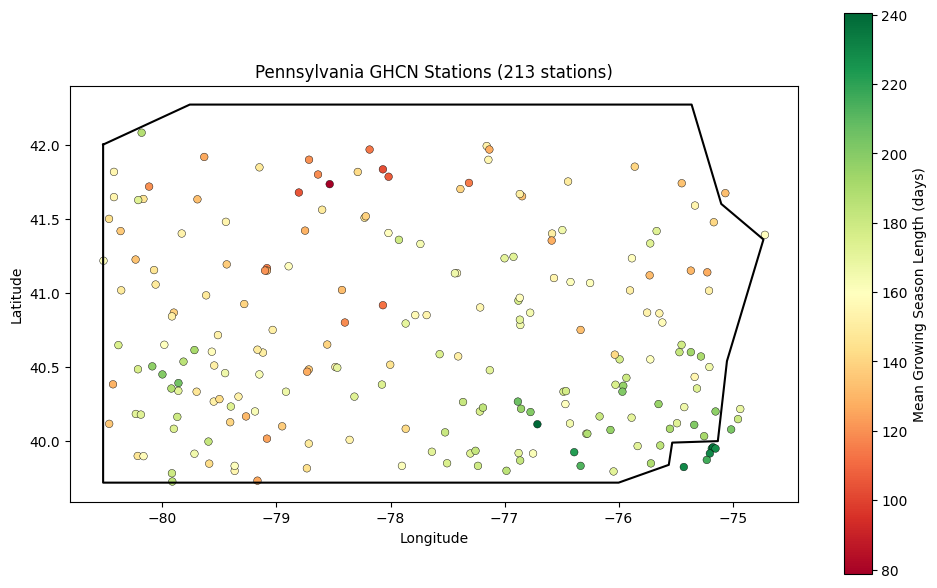

In [27]:
# Map of PA stations colored by mean growing season length
fig, ax = plt.subplots(figsize=(10, 6))

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([-80.8, -74.4, 39.5, 42.3], crs=ccrs.PlateCarree())

    # State borders and geographic features
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
    ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")

    sc = ax.scatter(stations["lon"], stations["lat"], c=stations["mean_gsl"],
                    cmap="RdYlGn", s=30, edgecolors="k", linewidths=0.3,
                    transform=ccrs.PlateCarree(), zorder=5)
    plt.colorbar(sc, label="Mean Growing Season Length (days)", shrink=0.7)
    ax.set_title(f"Pennsylvania GHCN Stations ({len(stations)} stations)")
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

except ImportError:
    # Fallback without cartopy: approximate PA border
    pa_lon = [-80.52, -79.76, -75.36, -75.10, -74.73, -75.05,
              -75.13, -75.53, -75.56, -76.00, -76.10, -79.48, -80.52, -80.52]
    pa_lat = [42.00, 42.27, 42.27, 41.60, 41.36, 40.54,
              40.00, 39.99, 39.84, 39.72, 39.72, 39.72, 39.72, 42.00]
    ax.plot(pa_lon, pa_lat, "k-", linewidth=1.5)

    sc = ax.scatter(stations["lon"], stations["lat"], c=stations["mean_gsl"],
                    cmap="RdYlGn", s=30, edgecolors="k", linewidths=0.3)
    plt.colorbar(sc, label="Mean Growing Season Length (days)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Pennsylvania GHCN Stations ({len(stations)} stations)")
    ax.set_aspect(1.3)

plt.tight_layout()
plt.show()

---
## 2. Column inventory

Every column in the dataset, with data type, coverage, and range.

In [28]:
# Column summary table
rows = []
for col in df.columns:
    n_valid = df[col].notna().sum()
    pct = 100 * n_valid / len(df)
    if df[col].dtype in ['float64', 'int64']:
        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "non_null": f"{n_valid}/{len(df)}",
            "coverage": f"{pct:.1f}%",
            "min": f"{df[col].min():.2f}",
            "max": f"{df[col].max():.2f}",
            "mean": f"{df[col].mean():.2f}",
        })
    else:
        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "non_null": f"{n_valid}/{len(df)}",
            "coverage": f"{pct:.1f}%",
            "min": "",
            "max": "",
            "mean": "",
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                    column   dtype    non_null coverage     min     max    mean
                station_id     str 10930/10930   100.0%                        
                      year   int64 10930/10930   100.0% 1874.00 2025.00 1966.81
     last_spring_frost_doy   int64 10930/10930   100.0%   58.00  182.00  123.48
    last_spring_frost_date     str 10930/10930   100.0%                        
      first_fall_frost_doy   int64 10930/10930   100.0%  182.00  356.00  284.96
     first_fall_frost_date     str 10930/10930   100.0%                        
     growing_season_length   int64 10930/10930   100.0%    9.00  275.00  161.48
                dtr_annual float64 10930/10930   100.0%    5.39   18.90   11.76
                dtr_spring float64 10926/10930   100.0%    4.12   22.18   12.66
                dtr_summer float64 10927/10930   100.0%  -34.50   20.07   12.87
               tmax_annual float64 10930/10930   100.0%    0.01   21.97   16.06
            prcp_annual_mm float64 10894

KeyError: 'dist_atlantic_km'

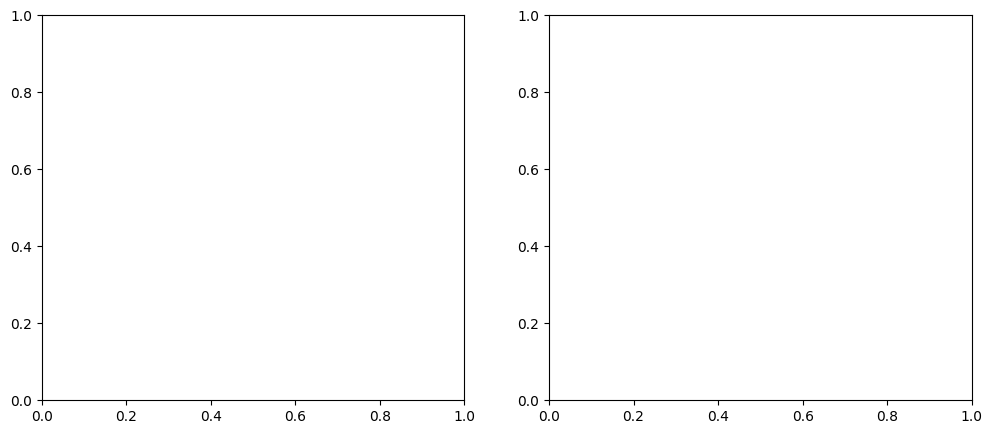

In [22]:
# GSL vs distance to water, colored by elevation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in [
    (axes[0], "dist_atlantic_km", "Distance to Atlantic/Gulf coast (km)"),
    (axes[1], "dist_greatlakes_km", "Distance to Great Lakes (km)"),
]:
    sc = ax.scatter(stations[col], stations["mean_gsl"],
                    c=stations["elev_m"], cmap="terrain", s=30,
                    edgecolors="k", linewidths=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Mean GSL (days)")

plt.colorbar(sc, ax=axes[1], label="Elevation (m)")
fig.suptitle("Growing season length vs distance to water bodies", fontsize=12)
plt.tight_layout()
plt.show()

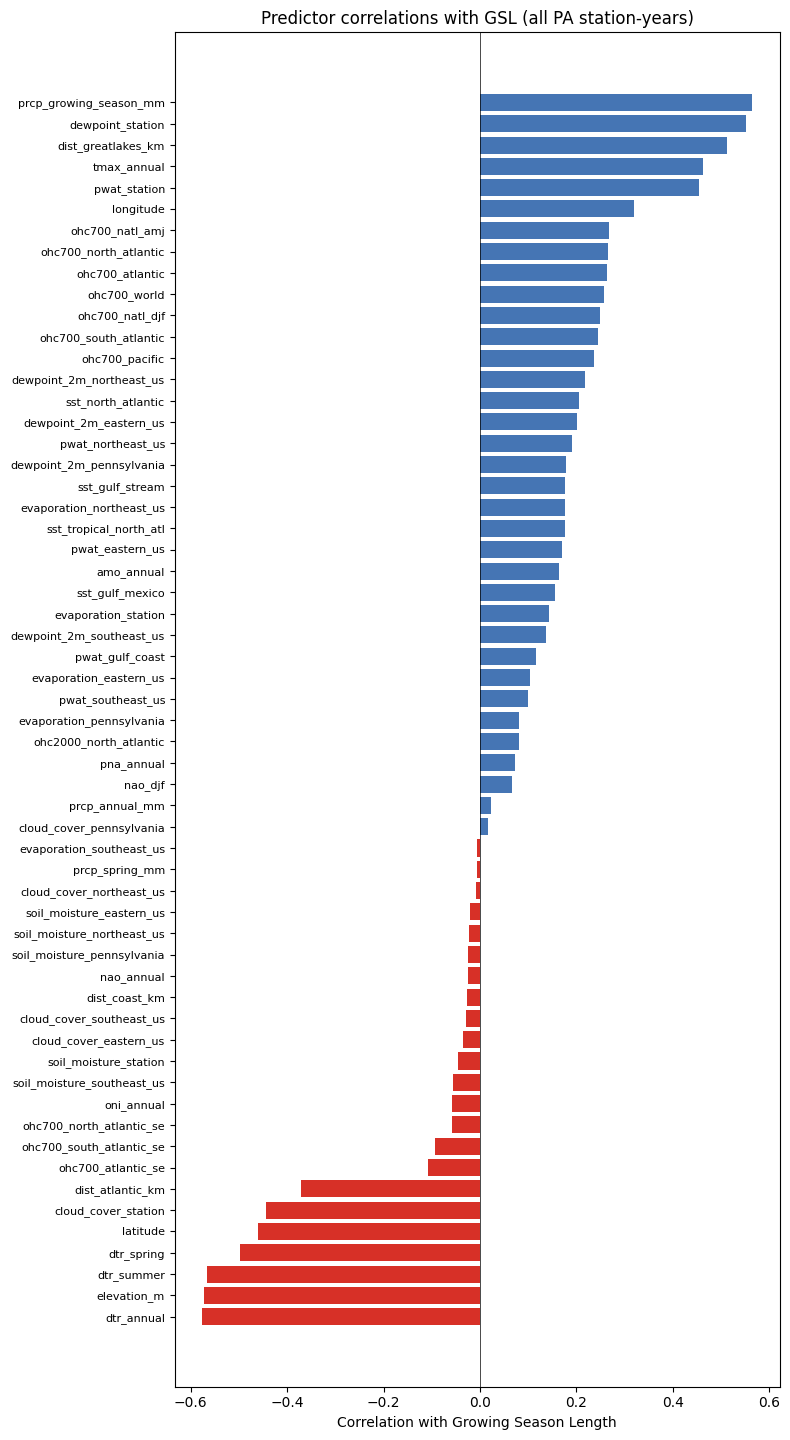


Top 10 strongest correlations:
dtr_annual                0.576126
elevation_m               0.572581
dtr_summer                0.566852
prcp_growing_season_mm    0.564454
dewpoint_station          0.550742
dist_greatlakes_km        0.512589
dtr_spring                0.497603
tmax_annual               0.463397
latitude                  0.459687
pwat_station              0.455292


In [23]:
# Correlations between GSL and all numeric predictors
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude ID-like and redundant columns
exclude = {"year", "last_spring_frost_doy", "first_fall_frost_doy"}
pred_cols = [c for c in numeric_cols if c not in exclude and c != "growing_season_length"]

corrs = df[pred_cols + ["growing_season_length"]].corr()["growing_season_length"].drop("growing_season_length")
corrs = corrs.dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, max(6, len(corrs) * 0.25)))
colors = ["#d73027" if v < 0 else "#4575b4" for v in corrs.values]
ax.barh(range(len(corrs)), corrs.values, color=colors)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index, fontsize=8)
ax.set_xlabel("Correlation with Growing Season Length")
ax.set_title("Predictor correlations with GSL (all PA station-years)")
ax.axvline(0, color="k", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 10 strongest correlations:")
print(corrs.abs().nlargest(10).to_string())

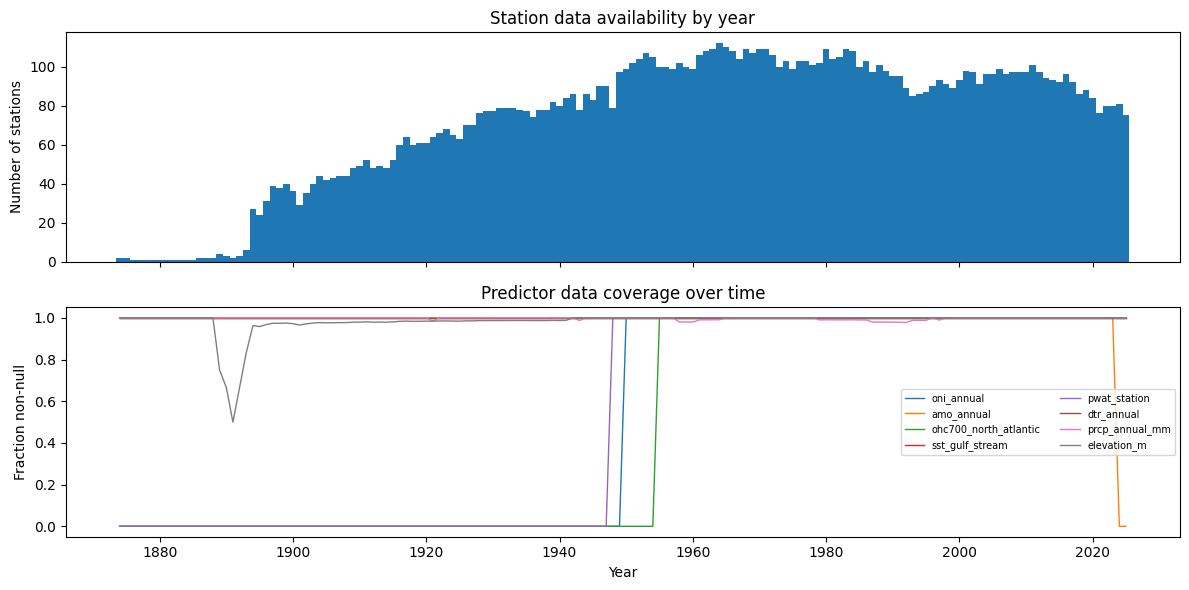

In [24]:
# Stations per year
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

counts = df.groupby("year")["station_id"].nunique()
axes[0].bar(counts.index, counts.values, width=1, edgecolor="none")
axes[0].set_ylabel("Number of stations")
axes[0].set_title("Station data availability by year")

# Predictor availability by year (fraction non-null)
key_preds = [c for c in ["oni_annual", "amo_annual", "ohc700_north_atlantic",
                          "sst_gulf_stream", "pwat_station", "dtr_annual",
                          "prcp_annual_mm", "elevation_m"]
             if c in df.columns]

for pred in key_preds:
    avail = df.groupby("year")[pred].apply(lambda x: x.notna().mean())
    axes[1].plot(avail.index, avail.values, label=pred, linewidth=1)

axes[1].set_ylabel("Fraction non-null")
axes[1].set_xlabel("Year")
axes[1].set_title("Predictor data coverage over time")
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()